In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input
from sklearn.metrics import confusion_matrix, classification_report

# TASK 1: LSTM FOR TEXT CLASSIFICATION

In [ ]:
# Load IMDB dataset
vocab_size = 10000
max_len = 180

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

In [ ]:
# Pad reviews to same length
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

print("Train Shape:", x_train.shape)
print("Test Shape:", x_test.shape)

Train Shape: (25000, 180)
Test Shape: (25000, 180)


In [ ]:
# Build LSTM text classification model
text_model = Sequential([
    Embedding(vocab_size, 100, input_length=max_len),
    LSTM(64),
    Dropout(0.4),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

In [ ]:
# Compile model
text_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

text_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train model
history_text = text_model.fit(
    x_train,
    y_train,
    epochs=4,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7784 - loss: 0.4540 - val_accuracy: 0.8652 - val_loss: 0.3160
Epoch 2/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9029 - loss: 0.2553 - val_accuracy: 0.8722 - val_loss: 0.3201
Epoch 3/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9348 - loss: 0.1809 - val_accuracy: 0.8594 - val_loss: 0.3519
Epoch 4/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9477 - loss: 0.1427 - val_accuracy: 0.8658 - val_loss: 0.3697


In [ ]:
# Evaluate model
test_loss, test_acc = text_model.evaluate(x_test, y_test)
print("Text Classification Test Accuracy:", test_acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8532 - loss: 0.4017
Text Classification Test Accuracy: 0.8532000184059143


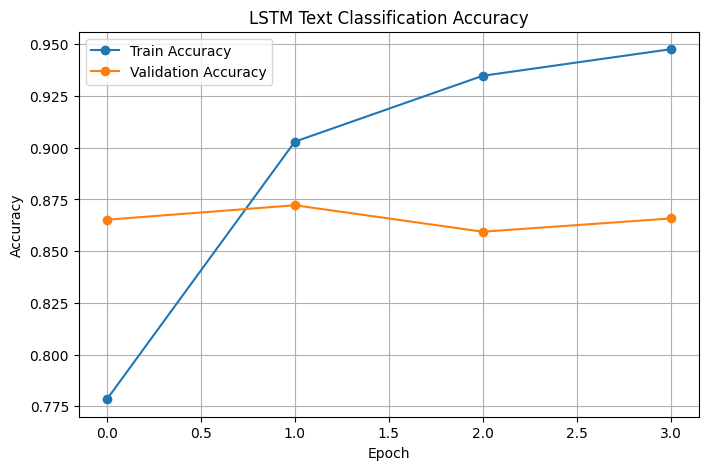

In [ ]:
# Plot accuracy and loss
plt.figure(figsize=(8, 5))
plt.plot(history_text.history["accuracy"], marker="o", label="Train Accuracy")
plt.plot(history_text.history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("LSTM Text Classification Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

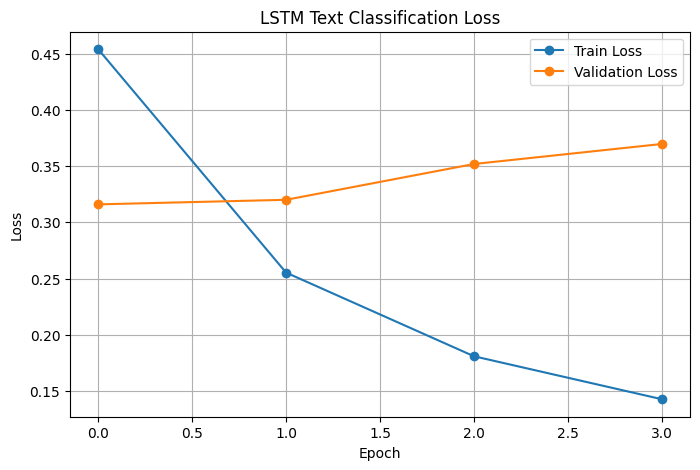

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_text.history["loss"], marker="o", label="Train Loss")
plt.plot(history_text.history["val_loss"], marker="o", label="Validation Loss")
plt.title("LSTM Text Classification Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step


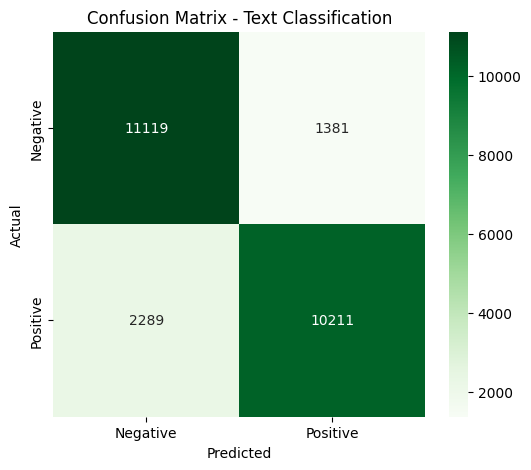

              precision    recall  f1-score   support

           0       0.83      0.89      0.86     12500
           1       0.88      0.82      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.86      0.85      0.85     25000
weighted avg       0.86      0.85      0.85     25000



In [ ]:
# Confusion matrix
y_pred_prob = text_model.predict(x_test)
y_pred = (y_pred_prob > 0.5).astype("int32")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.title("Confusion Matrix - Text Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, y_pred))

# TASK 2: LSTM SEQUENCE-TO-SEQUENCE MODEL
# Task: Reverse a Number Sequence

In [ ]:
# Create sequence dataset
num_samples = 8000
seq_len = 5
num_tokens = 10

X = np.random.randint(1, num_tokens, size=(num_samples, seq_len))
Y = np.flip(X, axis=1)

print("Input Example:", X[0])
print("Target Output:", Y[0])

Input Example: [1 2 6 3 7]
Target Output: [7 3 6 2 1]


In [ ]:
# One-hot encoding
X_onehot = tf.keras.utils.to_categorical(X, num_classes=num_tokens)
Y_onehot = tf.keras.utils.to_categorical(Y, num_classes=num_tokens)

In [ ]:
# Prepare decoder input
decoder_input_data = np.zeros_like(Y_onehot)
decoder_input_data[:, 1:, :] = Y_onehot[:, :-1, :]

In [ ]:
# Build encoder
encoder_inputs = Input(shape=(seq_len, num_tokens))
encoder_lstm = LSTM(80, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)

In [ ]:
# Build decoder
decoder_inputs = Input(shape=(seq_len, num_tokens))
decoder_lstm = LSTM(80, return_sequences=True, return_state=True)

decoder_outputs, _, _ = decoder_lstm(
    decoder_inputs,
    initial_state=[state_h, state_c]
)

In [ ]:
# Output layer
decoder_dense = Dense(num_tokens, activation="softmax")
decoder_outputs = decoder_dense(decoder_outputs)

In [ ]:
# Create complete Seq2Seq model
seq2seq_model = Model(
    [encoder_inputs, decoder_inputs],
    decoder_outputs
)

In [ ]:
# Compile model
seq2seq_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

seq2seq_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 5, 10)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 5, 10)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ [(None, 80),      │     29,120 │ input_layer_3[0]… │
│                     │ (None, 80),       │            │                   │
│                     │ (None, 80)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ [(None, 5, 80),   │     29,120 │ input_layer_4[0]… │
│                     │ (None, 80),       │            │ lstm_3[0][1],     │
│                     │ (None, 80)]       │            │ lstm_3[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 5, 10)     │        810 │ lstm_4[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 59,050 (230.66 KB)

 Trainable params: 59,050 (230.66 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train Seq2Seq model
history_seq = seq2seq_model.fit(
    [X_onehot, decoder_input_data],
    Y_onehot,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.2772 - loss: 2.1361 - val_accuracy: 0.3479 - val_loss: 1.8093
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3858 - loss: 1.5519 - val_accuracy: 0.4293 - val_loss: 1.3629
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5069 - loss: 1.2154 - val_accuracy: 0.6146 - val_loss: 1.0412
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7332 - loss: 0.8731 - val_accuracy: 0.8207 - val_loss: 0.7023
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8782 - loss: 0.5734 - val_accuracy: 0.9280 - val_loss: 0.4492
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9532 - loss: 0.3706 - val_accuracy: 0.9750 - val_loss: 0.2956
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9823 - loss: 0.2496 - val_accuracy: 0.9886 - val_loss: 0.2112
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9936 - loss: 0.1766 - val_accuracy: 0.9949 - val_loss

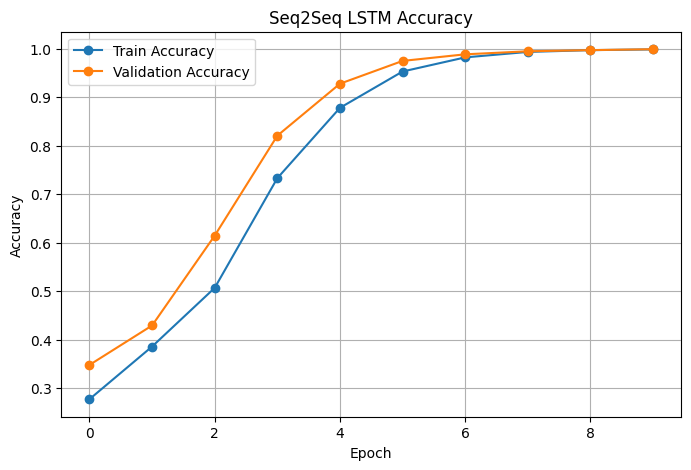

In [ ]:
# Plot Seq2Seq accuracy and loss
plt.figure(figsize=(8, 5))
plt.plot(history_seq.history["accuracy"], marker="o", label="Train Accuracy")
plt.plot(history_seq.history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Seq2Seq LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

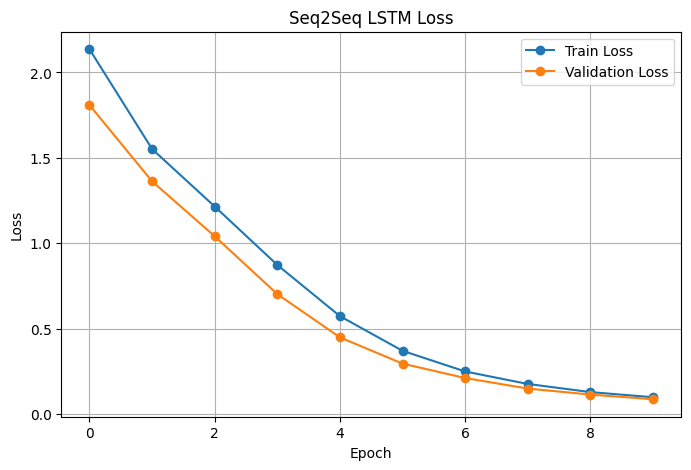

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_seq.history["loss"], marker="o", label="Train Loss")
plt.plot(history_seq.history["val_loss"], marker="o", label="Validation Loss")
plt.title("Seq2Seq LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()



In [ ]:
# Sample predictions
print("\nSeq2Seq Sample Predictions:")

for i in range(5):
    sample_x = X_onehot[i:i+1]
    sample_decoder = np.zeros((1, seq_len, num_tokens))

    prediction = seq2seq_model.predict(
        [sample_x, sample_decoder],
        verbose=0
    )

    predicted_sequence = np.argmax(prediction[0], axis=1)

    print("--------------------------------")
    print("Input Sequence:    ", X[i])
    print("Expected Output:   ", Y[i])
    print("Predicted Output:  ", predicted_sequence)


print("\nLAB 5 COMPLETED SUCCESSFULLY")


Seq2Seq Sample Predictions:
--------------------------------
Input Sequence:     [1 2 6 3 7]
Expected Output:    [7 3 6 2 1]
Predicted Output:   [7 7 7 7 7]
--------------------------------
Input Sequence:     [8 6 1 7 4]
Expected Output:    [4 7 1 6 8]
Predicted Output:   [4 4 4 4 1]
--------------------------------
Input Sequence:     [6 4 1 5 7]
Expected Output:    [7 5 1 4 6]
Predicted Output:   [7 7 7 7 7]
--------------------------------
Input Sequence:     [4 9 6 4 1]
Expected Output:    [1 4 6 9 4]
Predicted Output:   [1 1 1 1 4]
--------------------------------
Input Sequence:     [9 7 4 1 4]
Expected Output:    [4 1 4 7 9]
Predicted Output:   [4 4 4 4 4]

LAB 5 COMPLETED SUCCESSFULLY
